# Predicting Hepatitis C 🩺

#### If you like my work, It will be really great of you to upvote this notebook!
#### If not then you leaving a comment on what do I need to work on and improve will be really helpful!

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("dataset-uci.csv")  # replace with your path

# Preview
print(df.head())
print(df['Gallstone Status'].value_counts())

   Gallstone Status  Age  Gender  Comorbidity  Coronary Artery Disease (CAD)  \
0                 0   50       0            0                              0   
1                 0   47       0            1                              0   
2                 0   61       0            0                              0   
3                 0   41       0            0                              0   
4                 0   42       0            0                              0   

   Hypothyroidism  Hyperlipidemia  Diabetes Mellitus (DM)  Height  Weight  \
0               0               0                       0     185    92.8   
1               0               0                       0     176    94.5   
2               0               0                       0     171    91.1   
3               0               0                       0     168    67.7   
4               0               0                       0     178    89.6   

   ...  High Density Lipoprotein (HDL)  Triglyceride  \


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [23]:
df['Chol_HDL_Ratio'] = df['Total Cholesterol (TC)'] / (df['High Density Lipoprotein (HDL)'] + 1e-3)

df['TG_BMI_Index'] = df['Triglyceride'] * df['Body Mass Index (BMI)']

# df['ALP_ALT_Ratio'] = df['Alkaline Phosphatase (ALP)'] / (df['Alanin Aminotransferaz (ALT)'] + 1e-3)

# df['LeanMass_BMI_Ratio'] = df['Lean Mass (LM) (%)'] / (df['Body Mass Index (BMI)'] + 1e-3)

# df['VisceralFatDensity'] = df['Visceral Fat Area (VFA)'] / (df['Weight'] + 1e-3)

df['GallstoneRiskScore'] = (
    (df['Total Cholesterol (TC)'] > 200).astype(int) +
    (df['Triglyceride'] > 150).astype(int) +
    (df['Body Mass Index (BMI)'] > 30).astype(int) +
    (df['Alkaline Phosphatase (ALP)'] > 120).astype(int)
)




In [24]:
X = df.drop(columns=['Gallstone Status'])  # target column assumed to be 'Gallstones'
y = df['Gallstone Status']

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(max_iter=1000)

y_pred = cross_val_predict(model, X_scaled, y, cv=cv)

Stratified Logistic Regression Accuracy: 0.7774


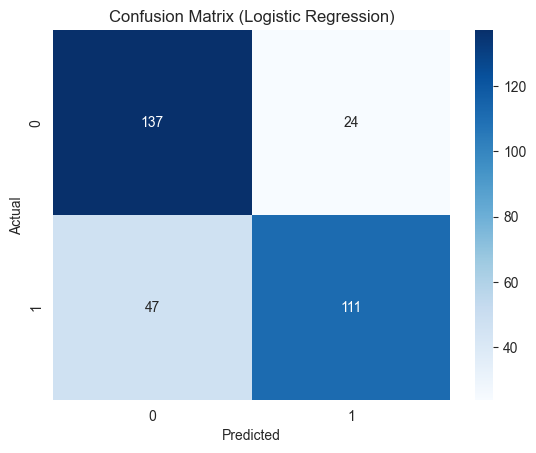

In [27]:
acc = accuracy_score(y, y_pred)
print(f"Stratified Logistic Regression Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Logistic Regression)")
plt.show()


In [28]:
print("Classification Report:")
print(classification_report(y, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.85      0.79       161
           1       0.82      0.70      0.76       158

    accuracy                           0.78       319
   macro avg       0.78      0.78      0.78       319
weighted avg       0.78      0.78      0.78       319



In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 42 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [105]:
target = 'Gallstone Status'  # 0 = No Gallstones, 1 = Gallstones


In [106]:
continuous_features = [
    'GlucoseCholRatio',
    'MuscleFatBalance',
    'LiverFunctionComposite',
    'AdiposityBurden',
    'LeanMass_BMI_Ratio',
    'ProteinDensity',
    'VisceralFatDensity'
]

binary_features = ['InflammatoryAnemiaScore']


In [95]:
from scipy.stats import ttest_ind

for feature in continuous_features:
    group_0 = df[df['Gallstone Status'] == 0][feature]
    group_1 = df[df['Gallstone Status'] == 1][feature]
    t_stat, p_val = ttest_ind(group_0, group_1)
    print(f"{feature}: t-stat = {t_stat:.4f}, p = {p_val:.4e}")



KeyError: 'GlucoseCholRatio'

In [83]:
from scipy.stats import chi2_contingency
import pandas as pd

for feature in binary_features:
    contingency_table = pd.crosstab(df[feature], df['Gallstone Status'])
    chi2, p_val, _, _ = chi2_contingency(contingency_table)
    print(f"{feature}: chi2 = {chi2:.4f}, p = {p_val:.4e}")


InflammatoryAnemiaScore: chi2 = 25.0119, p = 3.7046e-06
